In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv('gurgaon_properties_cleaned_v2.csv').drop_duplicates()

In [5]:
df.head()

,property_type,society,sector,price,price_per_sqft,Estimated_area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,ss,sector 85,1.18,7170.0,1646.0,Super Built up area 1640(152.36 sq.m.)Built Up...,2,2,3,4.0,West,Relatively New,This lovely 2 bhk apartment/flat in sector 85 ...,1640.0,1630.0,1620.0,0,0,0,0,0,0,49
1,house,independent,sector 57,8.31,24171.0,3438.0,Plot area 382(319.4 sq.m.),5,6,3+,4.0,North-East,Old Property,"Sushant lok-3\nBlock-B, corner villa at plot r...",NaN,3438.0,NaN,1,1,1,1,0,0,34
2,house,independent,sector 6,1.25,11574.0,1080.0,Plot area 120(100.34 sq.m.)Built Up area: 120 ...,5,5,1,2.0,South,New Property,Interested to sell independent house/villa.It ...,NaN,1080.0,NaN,0,0,0,1,0,0,0
3,flat,supertech araville,sector 79,0.95,6209.0,1530.0,Super Built up area 1530(142.14 sq.m.),2,2,3,7.0,North-East,New Property,"Right next to the new golf course road, m3m an...",1530.0,NaN,NaN,1,0,0,0,0,0,49
4,flat,ambience creacions,sector 22,3.20,11500.0,2783.0,Super Built up area 2781(258.36 sq.m.),3,4,3+,2.0,North-East,New Property,Right in heart of gurgaon and delhi is just 2k...,2781.0,NaN,NaN,0,0,0,0,0,0,42


In [6]:
df.shape

(3830, 24)

In [7]:
df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft',
       'Estimated_area', 'areaWithType', 'bedRoom', 'bathroom', 'balcony',
       'floorNum', 'facing', 'agePossession', 'description',
       'super_built_up_area', 'built_up_area', 'carpet_area', 'study room',
       'servant room', 'store room', 'pooja room', 'others', 'furnishing_type',
       'luxury_score'],
      dtype='object')

<Axes: xlabel='price', ylabel='Count'>

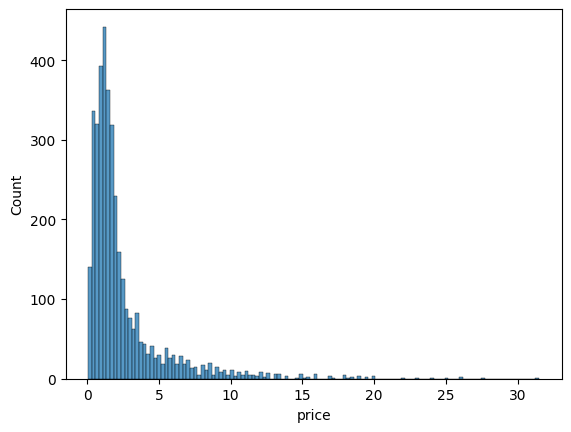

In [8]:
# outliers on the basis of price column
sns.histplot(df['price'])

<Axes: xlabel='price'>

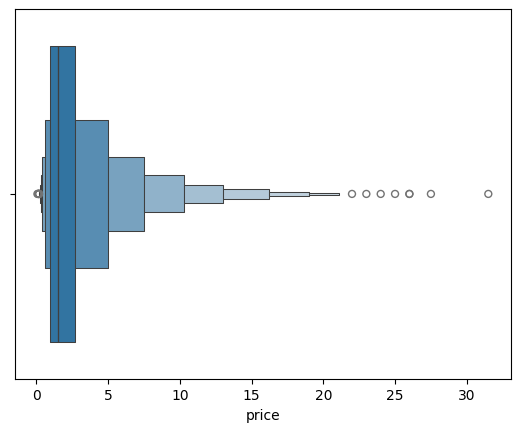

In [9]:
sns.boxenplot(x= df['price'])

<Axes: xlabel='price'>

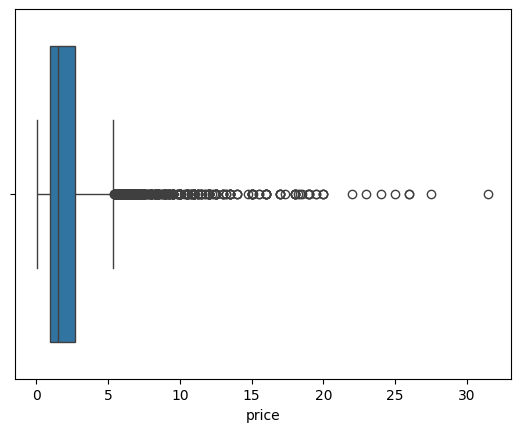

In [10]:
sns.boxplot(x=df['price'])

In [11]:
# Calculate the IQR for the 'price' column
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3-Q1
# Define bounds for outliers
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

# Identify outliers

outliers = df[(df['price']< lower_bound)| (df['price']> upper_bound)]


# Displaying the number of outliers and some statistics
num_outliers = outliers.shape[0]
outliers_price_stats = outliers['price'].describe()

print(f"Number of outliers: {num_outliers}")
print(f"Outliers statistics: {outliers_price_stats}")


Number of outliers: 439
Outliers statistics: count    439.000000
mean       9.164556
std        4.049009
min        5.400000
25%        6.350000
50%        8.000000
75%       10.550000
max       31.500000
Name: price, dtype: float64


In [12]:
outliers.sort_values('price',ascending=False).head(20)

,property_type,society,sector,price,price_per_sqft,Estimated_area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2914,house,arjun marg/ sector- 26 phase- 1/ golf course road,sector 26,31.50,35000.0,9000.0,Plot area 1000(836.13 sq.m.),7,9,3+,3.0,North-East,Moderately Old,Ultra modern super luxury duplex bungalow with...,NaN,9000.0,NaN,1,1,1,1,0,2,74
1841,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,Sushant lok 1 very prime location. This villa ...,NaN,11286.0,NaN,1,1,0,1,1,1,42
3639,house,independent,sector 26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,New Property,"Dlf phase 1 very prime location , this buildin...",NaN,3600.0,3150.0,1,1,1,1,0,2,72
3081,house,dlf city plots,sector 26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,2.0,North-East,New Property,505 sq.Y 6 bhk luxury villa \nIn dlf phase 1\n...,NaN,4545.0,NaN,1,1,0,1,1,1,138
3438,house,suncity township,sector 54,25.00,31111.0,8036.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,North,Moderately Old,"Suncity township in sector 54, gurgaon is a re...",NaN,9000.0,NaN,1,1,1,1,0,0,0
3392,house,emaar the palm springs,sector 54,24.00,600000.0,400.0,Plot area 400(37.16 sq.m.),5,5,2,1.0,North-East,Old Property,Emaar palm spring sector-54 (Villa) 400 gaj ba...,NaN,400.0,NaN,1,1,0,1,0,1,122
1068,house,independent,sector 26,23.00,25556.0,9000.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,South-West,Relatively New,1000 sq yards well maintained build up house a...,NaN,9000.0,NaN,1,1,1,1,0,1,145
3848,house,vipul tatvam villa,sector 48,22.00,26667.0,8250.0,Plot area 1000(836.13 sq.m.),5,6,3,3.0,Not Available,Moderately Old,A 1000 sqyd villa available for sale. The vill...,NaN,9000.0,NaN,0,1,0,0,0,0,54
893,house,independent,sector 26,20.00,44444.0,4500.0,Plot area 500(418.06 sq.m.),5,7,3+,3.0,West,Relatively New,"West facing kothi , area- 500 sq yard, \n5bhk-...",NaN,4500.0,NaN,0,1,0,1,0,2,97
2502,house,luxury dlf city floors,sector 26,20.00,48889.0,4091.0,Plot area 500(418.06 sq.m.),16,16,3+,4.0,Not Available,New Property,Prime location on dlf phase - 1 builder floor ...,NaN,4500.0,NaN,0,1,0,0,0,1,31


In [13]:
# on the basis of price col we can say that there are some genuine outliers but there are some data erros as well

### Price_per_sqft

<Axes: xlabel='price_per_sqft', ylabel='Count'>

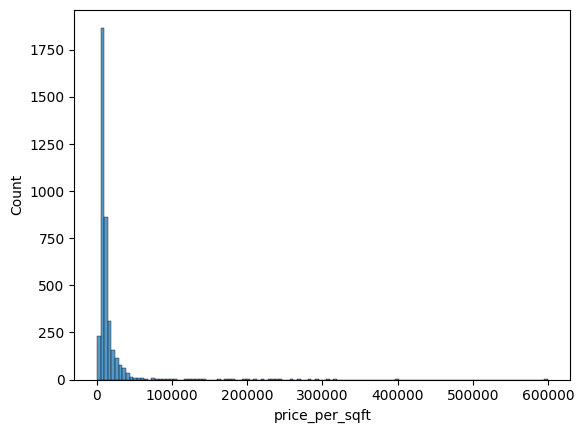

In [14]:
sns.histplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

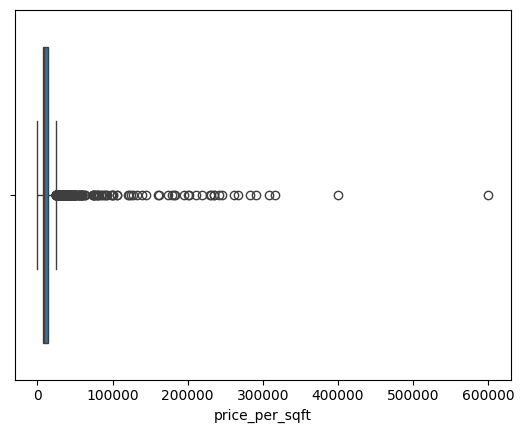

In [15]:
sns.boxplot(x=df['price_per_sqft'])

In [16]:
# Calculate the IQR for the 'price' column
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers_sqft.shape[0]
outliers_sqft_stats = outliers_sqft['price_per_sqft'].describe()

num_outliers, outliers_sqft_stats

(371,
 count       371.000000
 mean      53737.811321
 std       60660.260648
 min       24489.000000
 25%       28249.500000
 50%       33951.000000
 75%       43899.500000
 max      600000.000000
 Name: price_per_sqft, dtype: float64)

In [17]:
outliers_sqft['Estimated_area'] = outliers_sqft['Estimated_area'].apply(lambda x:x*9 if x<1000 else x)

C:\Users\priya\AppData\Local\Temp\ipykernel_34228\3966023227.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['Estimated_area'] = outliers_sqft['Estimated_area'].apply(lambda x:x*9 if x<1000 else x)


In [18]:
outliers_sqft['price_per_sqft']= round((outliers_sqft['price']*10000000)/outliers_sqft['Estimated_area'])

C:\Users\priya\AppData\Local\Temp\ipykernel_34228\4274044173.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['price_per_sqft']= round((outliers_sqft['price']*10000000)/outliers_sqft['Estimated_area'])


In [19]:
outliers_sqft['price_per_sqft'].describe()

count      371.000000
mean     28627.250674
std      12716.790152
min       2723.000000
25%      25000.000000
50%      29545.000000
75%      35443.500000
max      82540.000000
Name: price_per_sqft, dtype: float64

In [20]:
df.update(outliers_sqft)

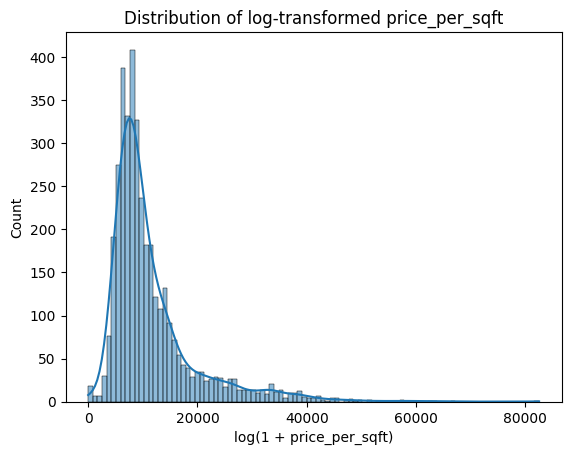

In [21]:
sns.histplot((df['price_per_sqft']), kde=True)
plt.xlabel("log(1 + price_per_sqft)")
plt.title("Distribution of log-transformed price_per_sqft")
plt.show()


<Axes: xlabel='price_per_sqft'>

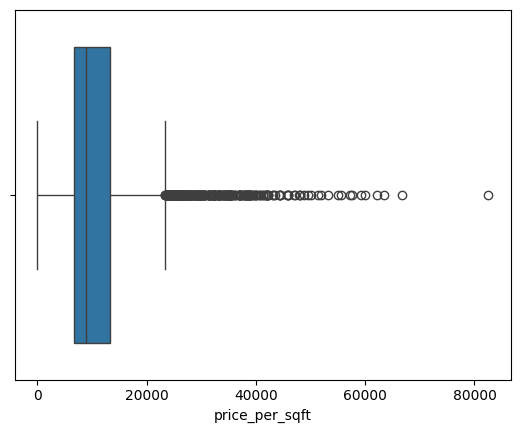

In [22]:
sns.boxplot(x=df['price_per_sqft'])

In [23]:
df[df['price_per_sqft']>50000]

,property_type,society,sector,price,price_per_sqft,Estimated_area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
754,house,independent,sector 25,16.00,59259.0,2700.0,Plot area 350(292.64 sq.m.)Built Up area: 325 ...,16,16,3+,4.0,West,New Property,"Dlf phase 2 very prime location , this buildin...",NaN,2925.0,2700.0,1,1,1,1,0,2,72
937,house,emaar the palm springs,sector 54,14.00,62222.0,2250.0,Plot area 250(209.03 sq.m.),4,5,3+,2.0,North,Old Property,Bathrooms\n Imported marble flooring in master...,NaN,2250.0,NaN,1,1,0,0,0,1,160
954,house,emaar mgf marbella,sector 51,18.00,55556.0,3240.0,Plot area 360(301.01 sq.m.),4,4,3+,3.0,East,Moderately Old,Check out this 4 bhk house for sale in sector ...,NaN,3240.0,NaN,1,1,0,1,0,2,75
2069,house,project housing board colony,sector 31,8.00,63492.0,1260.0,Built Up area: 140 (117.06 sq.m.),2,1,0,1.0,Not Available,Undefined,2bhk residential house for resale in project h...,NaN,140.0,NaN,0,0,0,0,0,0,0
2314,house,malibu towne,sector 47,8.50,53125.0,1600.0,Built Up area: 1600 (148.64 sq.m.),12,12,3+,4.0,North,New Property,It's a wholly distinctive home with three open...,NaN,1600.0,NaN,0,0,0,0,0,1,99
2484,flat,unitech vistas,sector 70,9.00,57508.0,1565.0,Built Up area: 1565 (145.39 sq.m.),3,3,0,7.0,Not Available,Undefined,Best in class property available at sector 70 ...,NaN,1565.0,NaN,0,0,0,0,0,0,0
3068,house,cloudnine cottages,sector 48,5.50,55000.0,1000.0,Plot area 1000(92.9 sq.m.),3,3,0,1.0,Not Available,Moderately Old,I am looking for buyer to purchase house/villa...,NaN,1000.0,NaN,0,0,0,0,0,0,0
3081,house,dlf city plots,sector 26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,2.0,North-East,New Property,505 sq.Y 6 bhk luxury villa \nIn dlf phase 1\n...,NaN,4545.0,NaN,1,1,0,1,1,1,138
3242,house,independent,sector 28,12.50,51440.0,2430.0,Plot area 270(225.75 sq.m.),16,17,3+,4.0,South,Relatively New,270 sq yard 4bhk par floor brand new building ...,NaN,2430.0,NaN,1,1,0,1,1,2,137
3391,house,unitech escape,sector 50,10.80,60000.0,1800.0,Plot area 290(242.48 sq.m.)Built Up area: 250 ...,4,4,3,2.0,North,Relatively New,The villa is very good location and 100% power...,NaN,2250.0,1800.0,1,1,1,1,0,1,103


In [24]:
df = df[df['price_per_sqft']<= 50000]

<Axes: xlabel='price_per_sqft'>

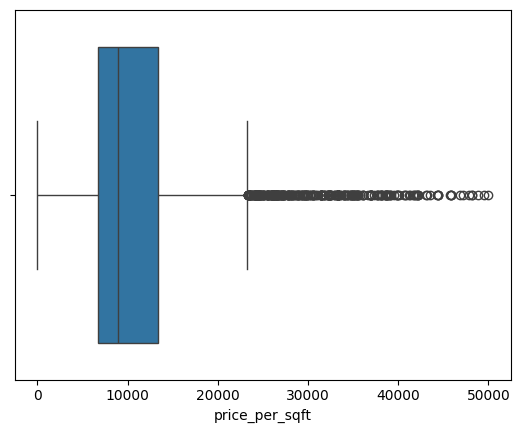

In [25]:
sns.boxplot(x=df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

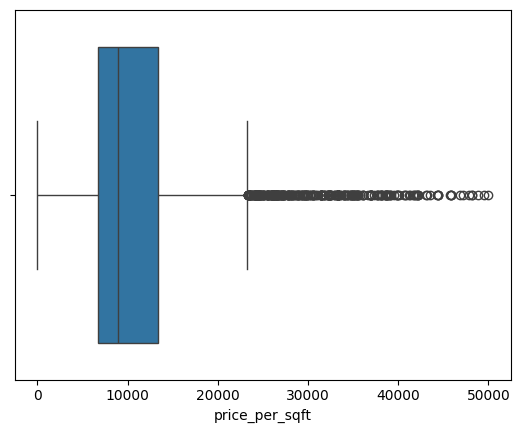

In [26]:
sns.boxplot(x=df['price_per_sqft'])

### Area

In [27]:
df[df['Estimated_area']>12000]

,property_type,society,sector,price,price_per_sqft,Estimated_area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
59,house,independent,sector 3,1.450,557.0,26032.0,Plot area 26000(2415.48 sq.m.),4,4,2,2.0,East,Moderately Old,East facing and new renovated. All amenities e...,NaN,26000.0,NaN,0,1,0,1,0,0,62
677,house,independent,sector 26,18.400,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,Dlf city phase 1 a block duplex kothi sale in ...,NaN,NaN,99000.00,0,1,1,1,0,1,60
785,house,independent,sector 50,5.000,232.0,215517.0,Plot area 2(1011.71 sq.m.),6,5,3+,2.0,Not Available,New Property,This 6 bhk house for sale in sector 50 gurgaon...,NaN,NaN,NaN,1,1,0,1,1,1,0
975,house,ganpati heights apartment,sector 13,1.250,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,Next to gurgaon bus depot. 10 mins walking dis...,NaN,NaN,NaN,0,0,0,0,1,0,7
1251,flat,signature the serenas,sector 48,0.280,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,1.0,North-West,Relatively New,This project is signature builder. On road soc...,NaN,NaN,48811.00,1,0,0,0,0,0,37
1269,flat,ramsons kshitij,sector 95,0.310,5.0,620000.0,Carpet area: 607936 (56479.1 sq.m.),2,2,1,1.0,North-East,Relatively New,"Ambitious, personable agent with 15 years of e...",NaN,NaN,607936.00,1,0,0,0,1,0,65
1295,flat,rof ananda,sector 95,0.380,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1,12.0,North,Relatively New,"Ambitious, personable agent with 15 years of e...",NaN,NaN,64412.00,0,0,0,0,0,0,51
1305,house,independent,sector 43,5.500,2716.0,20250.0,Plot area 215(179.77 sq.m.)Built Up area: 2850...,8,7,3+,3.0,East,Moderately Old,This is 215 sq yard independent well maintaine...,NaN,25650.0,20250.00,1,1,0,1,1,1,123
1483,house,unitech aspen greens,sector 50,6.950,4490.0,15479.0,Plot area 240(200.67 sq.m.)Built Up area: 2160...,3,3,1,2.0,North-East,Moderately Old,A magnificent lifestyle curated for just the e...,NaN,19440.0,15480.00,0,1,0,0,0,0,160
1497,flat,hcbs sports ville,sector 48,0.350,4.0,875000.0,Built Up area: 737147 (68483.2 sq.m.),2,2,2,8.0,Not Available,Relatively New,"View is awesome, towards the aravalli and fres...",NaN,737147.0,NaN,0,0,0,0,0,2,44


In [28]:
df = df[df['Estimated_area']<100000]

<Axes: xlabel='Estimated_area', ylabel='Density'>

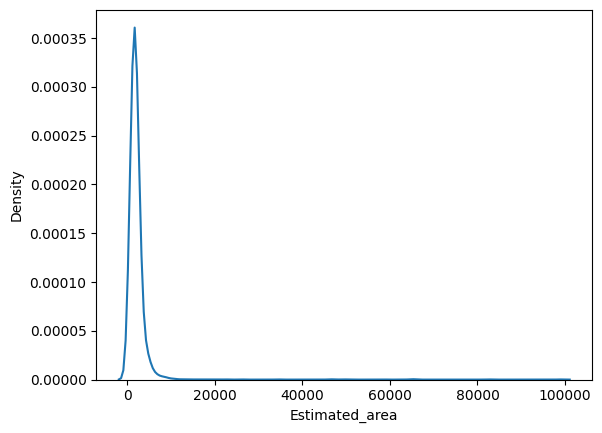

In [29]:
sns.kdeplot(df['Estimated_area'])

<Axes: xlabel='Estimated_area'>

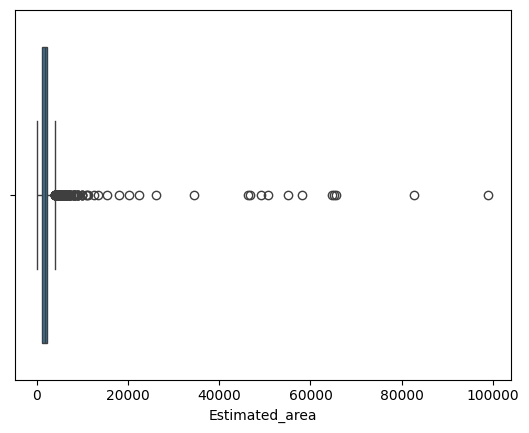

In [30]:
sns.boxplot(x=df['Estimated_area'])

In [31]:
df[df['Estimated_area']>10000].sort_values('Estimated_area',ascending=False)


,property_type,society,sector,price,price_per_sqft,Estimated_area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
677,house,independent,sector 26,18.400,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,Dlf city phase 1 a block duplex kothi sale in ...,NaN,NaN,99000.00,0,1,1,1,0,1,60
975,house,ganpati heights apartment,sector 13,1.250,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,Next to gurgaon bus depot. 10 mins walking dis...,NaN,NaN,NaN,0,0,0,0,1,0,7
1295,flat,rof ananda,sector 95,0.380,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1,12.0,North,Relatively New,"Ambitious, personable agent with 15 years of e...",NaN,NaN,64412.00,0,0,0,0,0,0,51
1558,house,dlf city plot phase 4,sector 28,13.000,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,Not Available,Undefined,Best in class property available at dlf city p...,NaN,NaN,7250.00,0,0,0,0,0,0,0
2517,flat,rof ananda,sector 95,0.375,58.0,64655.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2,10.0,East,New Property,Its rera approved and best built quality made ...,NaN,NaN,64529.00,1,0,0,0,0,0,15
3002,flat,pyramid elite,sector 86,0.460,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,Not Available,Under Construction,Near to dwarka expressway\nNear to airport,NaN,NaN,58141.00,0,0,0,0,0,0,15
2092,flat,rof ananda,sector 95,0.330,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1,13.0,South-West,Relatively New,"Ambitious, personable agent with 15 years of e...",NaN,NaN,54917.00,0,0,0,0,0,0,37
2103,house,independent,sector 51,5.500,1087.0,50598.0,Plot area 5620(4699.04 sq.m.)Built Up area: 82...,8,8,2,3.0,North-East,Relatively New,240sqyd 8bhk servant room ultra luxury kothi p...,NaN,74340.0,43740.00,0,0,0,1,0,1,49
1251,flat,signature the serenas,sector 48,0.280,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,1.0,North-West,Relatively New,This project is signature builder. On road soc...,NaN,NaN,48811.00,1,0,0,0,0,0,37
3453,house,independent,sector 25,7.300,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,Relatively New,"Floorwise builtup house with basement, stilt w...",NaN,52200.0,46800.00,0,1,1,0,0,1,109


In [32]:
df.drop(index=[677, 975, 1295, 2517, 3002, 2092, 1251, 3270, 3853, 1814, 59, 2103  ], inplace=True)

In [33]:
df['Estimated_area'].describe()

count     3780.000000
mean      1984.434392
std       1848.489685
min        145.000000
25%       1241.500000
50%       1739.000000
75%       2324.000000
max      65261.000000
Name: Estimated_area, dtype: float64

In [34]:
df[df['Estimated_area']>10000].sort_values('Estimated_area',ascending=False)


,property_type,society,sector,price,price_per_sqft,Estimated_area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1558,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,Not Available,Undefined,Best in class property available at dlf city p...,NaN,NaN,7250.00,0,0,0,0,0,0,0
3453,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,Relatively New,"Floorwise builtup house with basement, stilt w...",NaN,52200.0,46800.00,0,1,1,0,0,1,109
2515,house,independent,sector 57,6.25,2778.0,22498.0,Plot area 3100(2591.99 sq.m.)Built Up area: 26...,9,9,3+,3.0,North-East,New Property,Are you planning to buy your dream home? You c...,NaN,23940.0,22500.00,0,1,0,0,0,1,61
1305,house,independent,sector 43,5.50,2716.0,20250.0,Plot area 215(179.77 sq.m.)Built Up area: 2850...,8,7,3+,3.0,East,Moderately Old,This is 215 sq yard independent well maintaine...,NaN,25650.0,20250.00,1,1,0,1,1,1,123
2368,flat,godrej air,sector 85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,New Property,Godrej as a brand and very few densed society,NaN,NaN,18122.00,1,0,0,1,1,1,44
1483,house,unitech aspen greens,sector 50,6.95,4490.0,15479.0,Plot area 240(200.67 sq.m.)Built Up area: 2160...,3,3,1,2.0,North-East,Moderately Old,A magnificent lifestyle curated for just the e...,NaN,19440.0,15480.00,0,1,0,0,0,0,160
2288,flat,godrej icon,sector 88a,1.75,1384.0,12645.0,Carpet area: 1175.11,3,3,3+,6.0,Not Available,New Property,Godrej icon is one of the most popular destina...,NaN,NaN,1175.11,0,0,0,0,0,0,55
1841,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,Sushant lok 1 very prime location. This villa ...,NaN,11286.0,NaN,1,1,0,1,1,1,42
3289,flat,m3m golfestate,sector 65,13.20,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately Old,4 bedroom 11000 sq.Ft. Middle floor penthouse ...,NaN,NaN,11000.00,0,1,0,0,0,0,60
3663,house,independent,sector 48,5.50,5093.0,10799.0,Plot area 1200(1003.35 sq.m.)Built Up area: 35...,3,3,3+,2.0,West,Moderately Old,Three bedroom villa in the most serene area. W...,NaN,31500.0,NaN,1,1,0,1,1,0,49


In [35]:
df.loc[1558,'Estimated_area'] = 7250
df.loc[3453,'Estimated_area'] = 5800
df.loc[2515,'Estimated_area'] = 2660
df.loc[1305,'Estimated_area'] = 2850
df.loc[2368,'Estimated_area'] = 1812
df.loc[1483,'Estimated_area'] = 2160
df.loc[2288,'Estimated_area'] = 1175

In [36]:
df[df['Estimated_area']>10000].sort_values('Estimated_area',ascending=False)

,property_type,society,sector,price,price_per_sqft,Estimated_area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1841,house,independent,sector 43,27.5,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,Sushant lok 1 very prime location. This villa ...,NaN,11286.0,NaN,1,1,0,1,1,1,42
3289,flat,m3m golfestate,sector 65,13.2,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately Old,4 bedroom 11000 sq.Ft. Middle floor penthouse ...,NaN,NaN,11000.0,0,1,0,0,0,0,60
3663,house,independent,sector 48,5.5,5093.0,10799.0,Plot area 1200(1003.35 sq.m.)Built Up area: 35...,3,3,3+,2.0,West,Moderately Old,Three bedroom villa in the most serene area. W...,NaN,31500.0,NaN,1,1,0,1,1,0,49


<Axes: xlabel='Estimated_area', ylabel='Density'>

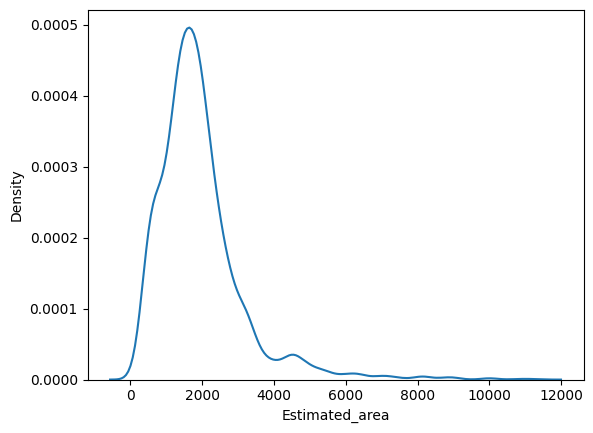

In [37]:
sns.kdeplot(df['Estimated_area'])

<Axes: xlabel='Estimated_area'>

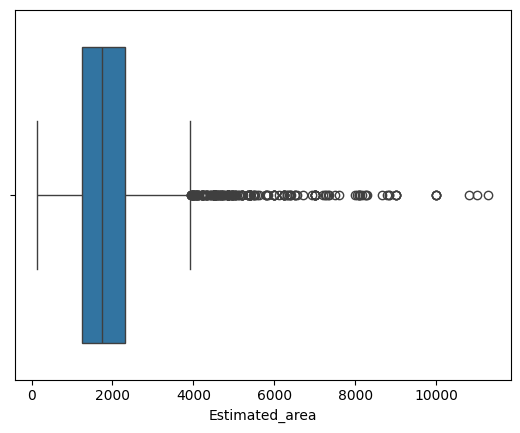

In [38]:
sns.boxplot(x=df['Estimated_area'])


### Bedroom

<Axes: xlabel='bedRoom', ylabel='Density'>

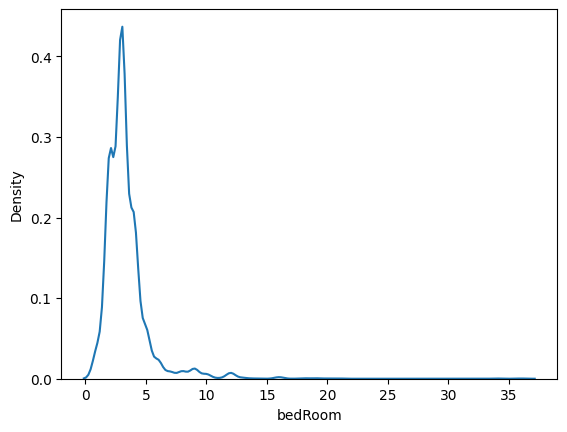

In [39]:
sns.kdeplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

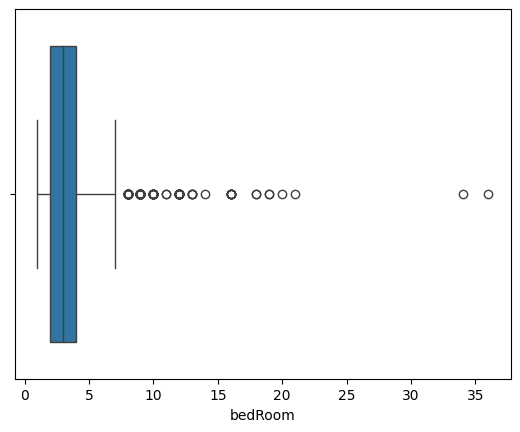

In [40]:
sns.boxplot(x=df['bedRoom'])

In [41]:
df['bedRoom'].describe()

count    3780.000000
mean        3.355026
std         1.969304
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        36.000000
Name: bedRoom, dtype: float64

In [42]:
df[df['bedRoom'] > 10].sort_values('bedRoom',ascending=False)

,property_type,society,sector,price,price_per_sqft,Estimated_area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2065,house,independent,sector 13,2.25,6944.0,3240.0,Plot area 360(301.01 sq.m.),36,36,2,3.0,East,Moderately Old,This property is having 36 rooms with attached...,NaN,3240.0,NaN,0,1,0,0,0,0,7
67,house,manohar nagar,sector 8,5.60,12444.0,4500.0,Plot area 500(418.06 sq.m.)Built Up area: 500 ...,34,34,3+,4.0,Not Available,New Property,This is a newly constructed building. With pro...,NaN,4500.0,NaN,0,0,0,0,0,1,0
3255,house,independent,sector 54,5.00,43066.0,1161.0,Plot area 129(107.86 sq.m.),21,21,3+,5.0,North,Relatively New,"129 sq yd plot size. 5 floors built up , fully...",NaN,1161.0,NaN,0,1,0,0,0,2,49
2591,house,independent,sector 43,4.50,39062.0,1152.0,Plot area 128(107.02 sq.m.),20,20,3+,4.0,East,Relatively New,Best for investment purpose. 3l rupees monthly...,NaN,1152.0,NaN,0,1,0,0,0,2,22
2107,house,independent,sector 17a,3.87,5160.0,7500.0,Plot area 1623(150.78 sq.m.)Built Up area: 750...,19,17,3+,5.0,North-West,Relatively New,The building is equipped with modern fittings....,NaN,7500.0,NaN,1,0,1,0,0,0,68
616,house,independent,sector 17a,3.93,24214.0,1623.0,Plot area 1623(150.78 sq.m.)Built Up area: 162...,19,17,3,4.0,North-West,Relatively New,"8% return yearly, very safe sector, supportive...",NaN,1622.0,NaN,1,1,1,1,0,0,74
993,house,independent,sector 54,5.50,38194.0,1440.0,Plot area 160(133.78 sq.m.),18,18,3+,4.0,South-West,Relatively New,18 bed room newly built up in 160 yds plot is ...,NaN,1440.0,NaN,0,1,0,0,0,2,70
1189,house,private house,sector 55,7.05,46906.0,1503.0,Plot area 167(139.63 sq.m.),18,18,3+,4.0,North-East,Relatively New,18furnished rooms with all interior and goods ...,NaN,1503.0,NaN,0,0,0,0,1,2,57
1311,house,independent,sector 40,12.00,38986.0,3078.0,Plot area 342(285.96 sq.m.),16,16,3+,4.0,Not Available,New Property,Ready to move in simplex kothi available for s...,NaN,3078.0,NaN,1,1,1,1,0,1,0
1778,house,independent,sector 56,12.39,45889.0,2700.0,Plot area 300(250.84 sq.m.),16,18,3+,4.0,North-East,New Property,Check out this 16 bhk house for sale in sector...,NaN,2700.0,NaN,0,1,0,1,0,1,49


In [43]:
df = df[df['bedRoom'] <= 10]

In [44]:
df.shape

(3732, 24)

C:\Users\priya\AppData\Local\Temp\ipykernel_34228\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

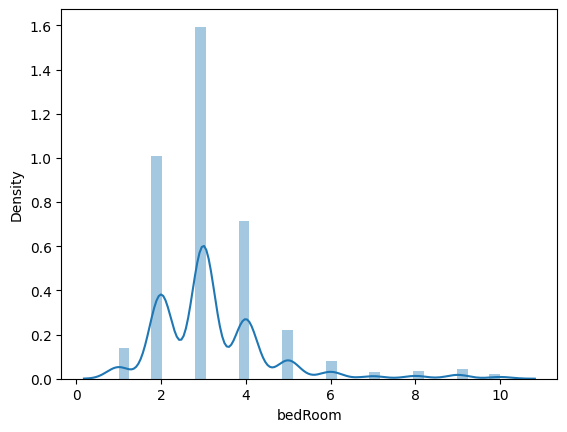

In [45]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

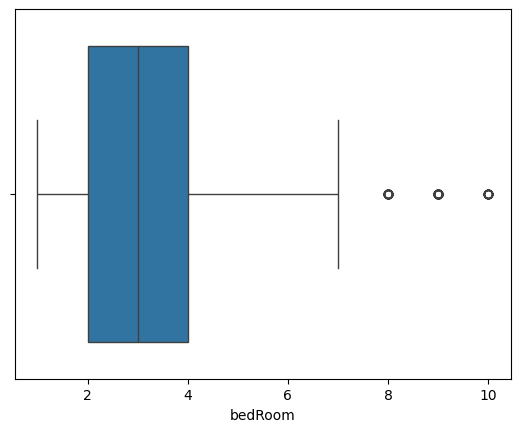

In [46]:
sns.boxplot(x=df['bedRoom'])

In [47]:
df['bedRoom'].describe()

count    3732.000000
mean        3.211415
std         1.408535
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: bedRoom, dtype: float64

### Bathroom

<Axes: xlabel='bathroom', ylabel='Count'>

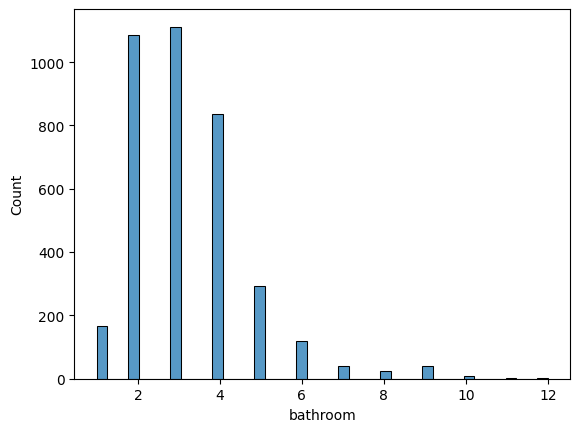

In [48]:
sns.histplot(df['bathroom'])

<Axes: xlabel='bathroom'>

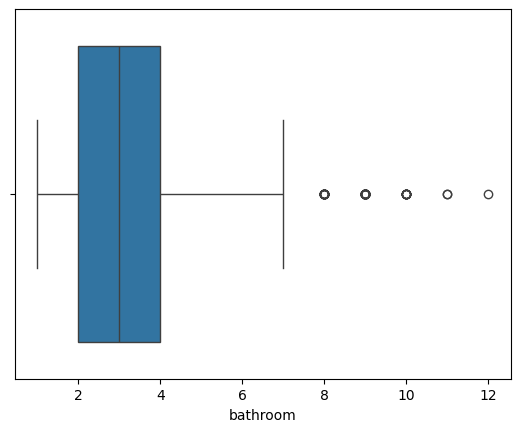

In [49]:
sns.boxplot(x=df['bathroom'])

In [50]:
df[df['bathroom'] > 10].sort_values('bathroom',ascending=False)

,property_type,society,sector,price,price_per_sqft,Estimated_area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1749,house,adani brahma samsara,sector 60,18.02,28200.0,6390.0,Built Up area: 6390 (593.65 sq.m.),9,12,3+,3.0,North-East,Relatively New,An impeccable opportunity is here for those wh...,NaN,6390.0,NaN,0,1,0,0,0,1,146
331,house,independent,sector 24,11.00,28902.0,3806.0,Plot area 3806.45(353.63 sq.m.)Built Up area: ...,8,11,3+,3.0,East,Old Property,Independent house available for sale.,NaN,5000.0,NaN,1,1,0,1,1,1,39
2555,house,independent,sector 39,7.00,10000.0,7000.0,Plot area 350(32.52 sq.m.)Built Up area: 7000 ...,10,11,3+,4.0,South-East,Relatively New,"Luxury house 10 bhk, floor wise, basement plus...",NaN,7000.0,NaN,0,0,0,1,0,2,38


In [51]:
df.head()

,property_type,society,sector,price,price_per_sqft,Estimated_area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,ss,sector 85,1.18,7170.0,1646.0,Super Built up area 1640(152.36 sq.m.)Built Up...,2,2,3,4.0,West,Relatively New,This lovely 2 bhk apartment/flat in sector 85 ...,1640.0,1630.0,1620.0,0,0,0,0,0,0,49
1,house,independent,sector 57,8.31,24171.0,3438.0,Plot area 382(319.4 sq.m.),5,6,3+,4.0,North-East,Old Property,"Sushant lok-3\nBlock-B, corner villa at plot r...",NaN,3438.0,NaN,1,1,1,1,0,0,34
2,house,independent,sector 6,1.25,11574.0,1080.0,Plot area 120(100.34 sq.m.)Built Up area: 120 ...,5,5,1,2.0,South,New Property,Interested to sell independent house/villa.It ...,NaN,1080.0,NaN,0,0,0,1,0,0,0
3,flat,supertech araville,sector 79,0.95,6209.0,1530.0,Super Built up area 1530(142.14 sq.m.),2,2,3,7.0,North-East,New Property,"Right next to the new golf course road, m3m an...",1530.0,NaN,NaN,1,0,0,0,0,0,49
4,flat,ambience creacions,sector 22,3.20,11500.0,2783.0,Super Built up area 2781(258.36 sq.m.),3,4,3+,2.0,North-East,New Property,Right in heart of gurgaon and delhi is just 2k...,2781.0,NaN,NaN,0,0,0,0,0,0,42


### super built up area

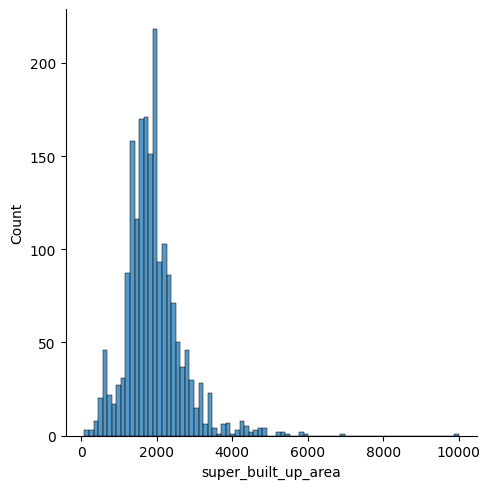

In [52]:
sns.displot(df['super_built_up_area'])

<Axes: xlabel='super_built_up_area'>

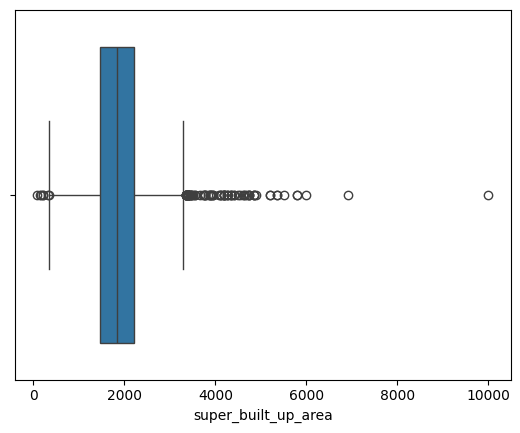

In [53]:
sns.boxplot(x=df['super_built_up_area'])

In [54]:
df['super_built_up_area'].describe()

count     1894.000000
mean      1921.049921
std        765.228732
min         89.000000
25%       1466.250000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

In [55]:
df[df['super_built_up_area']>6000]

,property_type,society,sector,price,price_per_sqft,Estimated_area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
660,flat,bestech park view grand spa,sector 81,4.7,6786.0,6926.0,Super Built up area 6926(643.45 sq.m.),4,4,3+,19.0,North,Relatively New,Semi furnished 4bhk 6926sqft penthouse with pe...,6926.0,NaN,NaN,0,1,0,0,0,1,140
3751,flat,krrish provence estate,sector 58,7.5,7500.0,10000.0,Super Built up area 10000(929.03 sq.m.),5,6,3+,23.0,North-East,Relatively New,"It is a beautiful penthouse with 10,000/- Sqft...",10000.0,NaN,NaN,0,1,0,1,1,0,49


### built up area

C:\Users\priya\AppData\Local\Temp\ipykernel_34228\3494228458.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['built_up_area'])


<Axes: xlabel='built_up_area', ylabel='Density'>

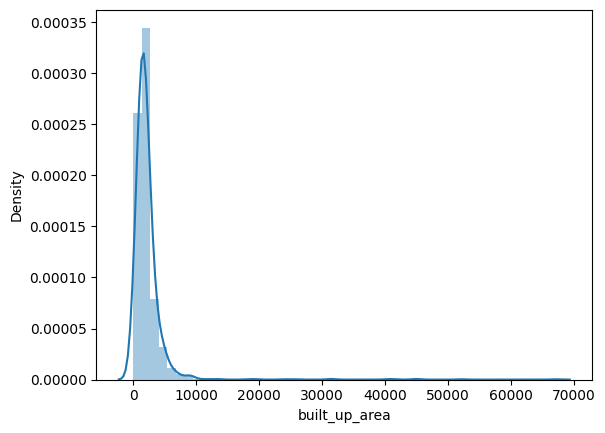

In [56]:
sns.distplot(df['built_up_area'])

In [57]:
condition = (
    (df['property_type'] == 'house') &
    (df['built_up_area'].notna()) &
    (df['Estimated_area'].notna()) &
    (df['built_up_area'] > 1.5 * df['Estimated_area'])
)

df.loc[condition, 'built_up_area'] = df.loc[condition, 'Estimated_area']


C:\Users\priya\AppData\Local\Temp\ipykernel_34228\3494228458.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['built_up_area'])


<Axes: xlabel='built_up_area', ylabel='Density'>

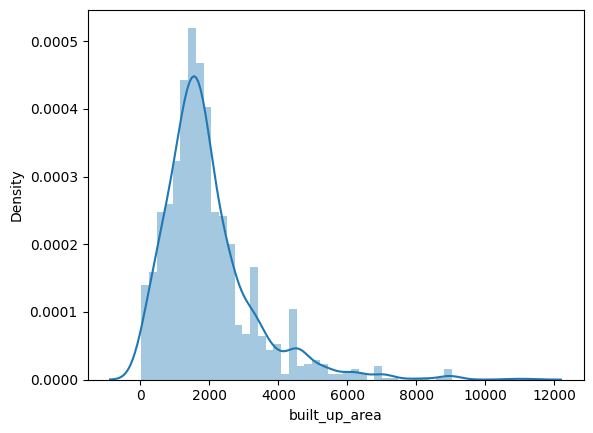

In [58]:
sns.distplot(df['built_up_area'])

<Axes: xlabel='built_up_area'>

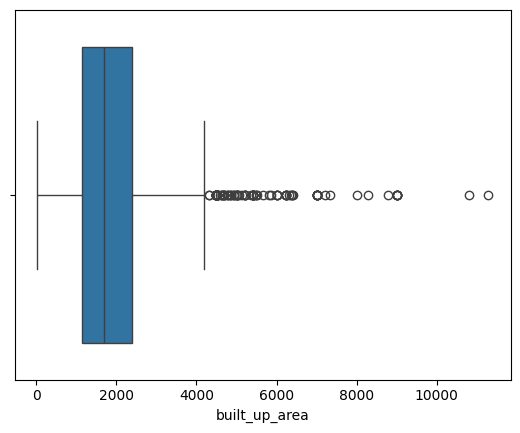

In [59]:
sns.boxplot(x=df['built_up_area'])

In [60]:
df[df['built_up_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,Estimated_area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1841,house,independent,sector 43,27.5,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,Sushant lok 1 very prime location. This villa ...,NaN,11286.0,NaN,1,1,0,1,1,1,42
3663,house,independent,sector 48,5.5,5093.0,10799.0,Plot area 1200(1003.35 sq.m.)Built Up area: 35...,3,3,3+,2.0,West,Moderately Old,Three bedroom villa in the most serene area. W...,NaN,10799.0,NaN,1,1,0,1,1,0,49


### carpet area

C:\Users\priya\AppData\Local\Temp\ipykernel_34228\3905767603.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['carpet_area'])


<Axes: xlabel='carpet_area', ylabel='Density'>

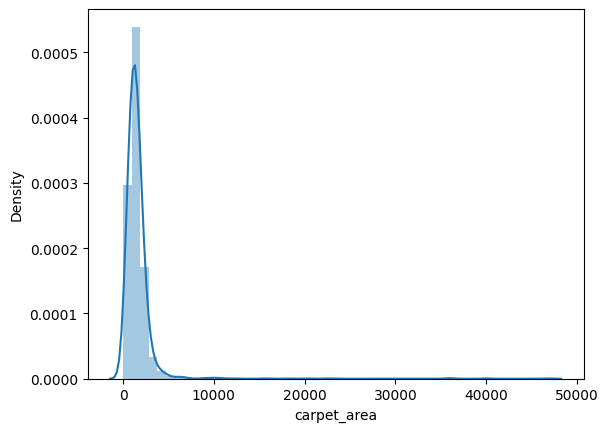

In [61]:
sns.distplot(df['carpet_area'])

<Axes: xlabel='carpet_area'>

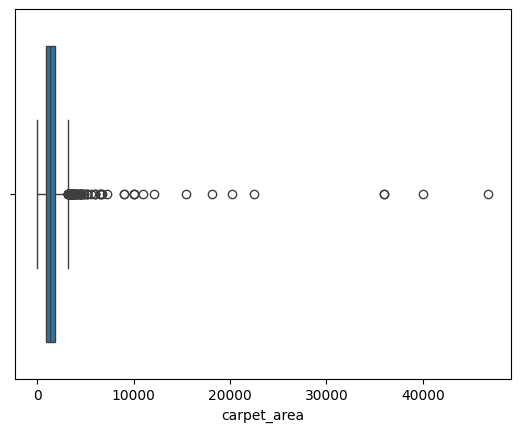

In [62]:
sns.boxplot(x=df['carpet_area'])

In [63]:
df[df['carpet_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,Estimated_area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
581,house,ansal api spanish court,sector 2,2.90,18626.0,1557.0,Plot area 173(144.65 sq.m.)Built Up area: 1415...,4,4,3,2.0,North,Relatively New,On sale 173 sq yrds built up house park facing...,NaN,1557.0,12150.0,0,0,1,0,0,1,49
1305,house,independent,sector 43,5.50,2716.0,2850.0,Plot area 215(179.77 sq.m.)Built Up area: 2850...,8,7,3+,3.0,East,Moderately Old,This is 215 sq yard independent well maintaine...,NaN,2850.0,20250.0,1,1,0,1,1,1,123
1393,house,ansals palam vihar,sector 2,5.70,14729.0,3870.0,Plot area 430(359.53 sq.m.)Built Up area: 4550...,5,5,2,2.0,North-East,Old Property,"This is 430 sq yard independence house ,very b...",NaN,3870.0,40050.0,0,0,0,1,0,2,94
1483,house,unitech aspen greens,sector 50,6.95,4490.0,2160.0,Plot area 240(200.67 sq.m.)Built Up area: 2160...,3,3,1,2.0,North-East,Moderately Old,A magnificent lifestyle curated for just the e...,NaN,2160.0,15480.0,0,1,0,0,0,0,160
2368,flat,godrej air,sector 85,2.50,1379.0,1812.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,New Property,Godrej as a brand and very few densed society,NaN,NaN,18122.0,1,0,0,1,1,1,44
2515,house,independent,sector 57,6.25,2778.0,2660.0,Plot area 3100(2591.99 sq.m.)Built Up area: 26...,9,9,3+,3.0,North-East,New Property,Are you planning to buy your dream home? You c...,NaN,2660.0,22500.0,0,1,0,0,0,1,61
3289,flat,m3m golfestate,sector 65,13.20,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately Old,4 bedroom 11000 sq.Ft. Middle floor penthouse ...,NaN,NaN,11000.0,0,1,0,0,0,0,60
3453,house,independent,sector 25,7.30,1560.0,5800.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,Relatively New,"Floorwise builtup house with basement, stilt w...",NaN,5800.0,46800.0,0,1,1,0,0,1,109
3650,house,independent,sector 23,5.65,17706.0,3191.0,Plot area 342(285.96 sq.m.)Built Up area: 5000...,7,7,3+,2.0,West,Moderately Old,The property is very well located in sector 23...,NaN,3191.0,36000.0,0,1,0,1,0,0,68
3887,house,unitech espace,sector 50,7.45,34491.0,2160.0,Plot area 240(200.67 sq.m.)Built Up area: 4500...,4,4,3,3.0,Not Available,Old Property,"240 sq.Yds old built duplex villa on sale, at ...",NaN,2160.0,36000.0,0,1,0,0,0,1,59


In [64]:
df.loc[2368,'carpet_area'] = 1812

In [65]:
condition_carpet = (
    (df['property_type'] == 'house') &
    (df['carpet_area'].notna()) &
    (df['Estimated_area'].notna()) &
    (df['carpet_area'] > 1.5 * df['Estimated_area'])
)

df.loc[condition_carpet, 'carpet_area'] = df.loc[condition_carpet, 'Estimated_area']


In [66]:
df[df['carpet_area'] > 15000]

,property_type,society,sector,price,price_per_sqft,Estimated_area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score


In [67]:
df.drop(index=[2368], inplace=True)

<Axes: xlabel='carpet_area'>

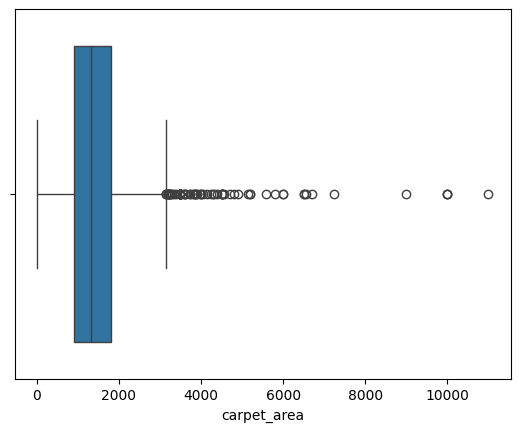

In [68]:
sns.boxplot(x=df['carpet_area'])

In [69]:
df.head()

,property_type,society,sector,price,price_per_sqft,Estimated_area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,ss,sector 85,1.18,7170.0,1646.0,Super Built up area 1640(152.36 sq.m.)Built Up...,2,2,3,4.0,West,Relatively New,This lovely 2 bhk apartment/flat in sector 85 ...,1640.0,1630.0,1620.0,0,0,0,0,0,0,49
1,house,independent,sector 57,8.31,24171.0,3438.0,Plot area 382(319.4 sq.m.),5,6,3+,4.0,North-East,Old Property,"Sushant lok-3\nBlock-B, corner villa at plot r...",NaN,3438.0,NaN,1,1,1,1,0,0,34
2,house,independent,sector 6,1.25,11574.0,1080.0,Plot area 120(100.34 sq.m.)Built Up area: 120 ...,5,5,1,2.0,South,New Property,Interested to sell independent house/villa.It ...,NaN,1080.0,NaN,0,0,0,1,0,0,0
3,flat,supertech araville,sector 79,0.95,6209.0,1530.0,Super Built up area 1530(142.14 sq.m.),2,2,3,7.0,North-East,New Property,"Right next to the new golf course road, m3m an...",1530.0,NaN,NaN,1,0,0,0,0,0,49
4,flat,ambience creacions,sector 22,3.20,11500.0,2783.0,Super Built up area 2781(258.36 sq.m.),3,4,3+,2.0,North-East,New Property,Right in heart of gurgaon and delhi is just 2k...,2781.0,NaN,NaN,0,0,0,0,0,0,42


C:\Users\priya\AppData\Local\Temp\ipykernel_34228\3385064764.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['luxury_score'])


<Axes: xlabel='luxury_score', ylabel='Density'>

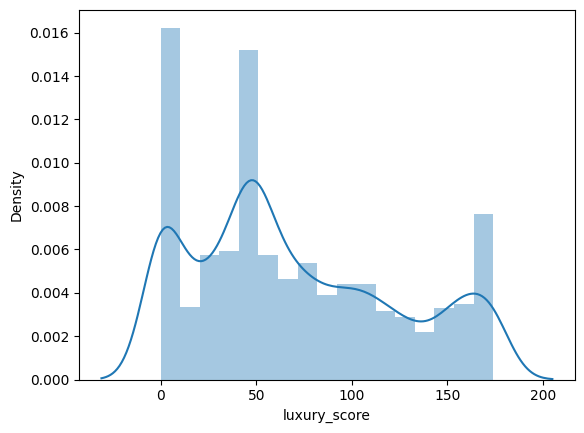

In [70]:
sns.distplot(df['luxury_score'])

<Axes: ylabel='luxury_score'>

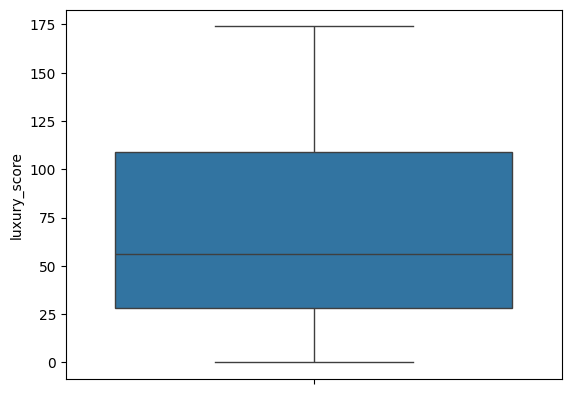

In [71]:
sns.boxplot(df['luxury_score'])

In [72]:
df.shape

(3731, 24)

In [73]:
df['price_per_sqft'] = round((df['price']*10000000)/df['Estimated_area'])

In [74]:
df.head()

,property_type,society,sector,price,price_per_sqft,Estimated_area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,ss,sector 85,1.18,7169.0,1646.0,Super Built up area 1640(152.36 sq.m.)Built Up...,2,2,3,4.0,West,Relatively New,This lovely 2 bhk apartment/flat in sector 85 ...,1640.0,1630.0,1620.0,0,0,0,0,0,0,49
1,house,independent,sector 57,8.31,24171.0,3438.0,Plot area 382(319.4 sq.m.),5,6,3+,4.0,North-East,Old Property,"Sushant lok-3\nBlock-B, corner villa at plot r...",NaN,3438.0,NaN,1,1,1,1,0,0,34
2,house,independent,sector 6,1.25,11574.0,1080.0,Plot area 120(100.34 sq.m.)Built Up area: 120 ...,5,5,1,2.0,South,New Property,Interested to sell independent house/villa.It ...,NaN,1080.0,NaN,0,0,0,1,0,0,0
3,flat,supertech araville,sector 79,0.95,6209.0,1530.0,Super Built up area 1530(142.14 sq.m.),2,2,3,7.0,North-East,New Property,"Right next to the new golf course road, m3m an...",1530.0,NaN,NaN,1,0,0,0,0,0,49
4,flat,ambience creacions,sector 22,3.20,11498.0,2783.0,Super Built up area 2781(258.36 sq.m.),3,4,3+,2.0,North-East,New Property,Right in heart of gurgaon and delhi is just 2k...,2781.0,NaN,NaN,0,0,0,0,0,0,42


C:\Users\priya\AppData\Local\Temp\ipykernel_34228\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

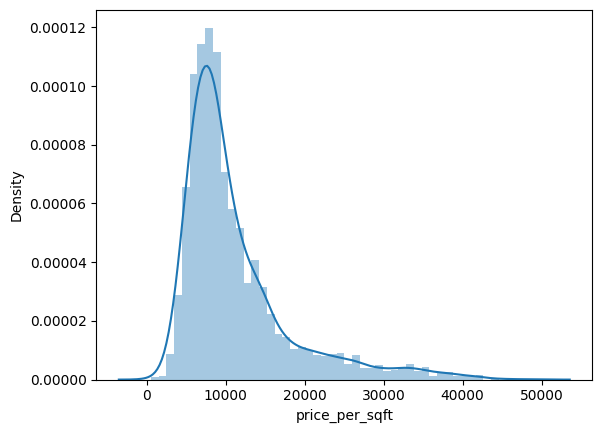

In [75]:
sns.distplot(df['price_per_sqft'])

<Axes: ylabel='price_per_sqft'>

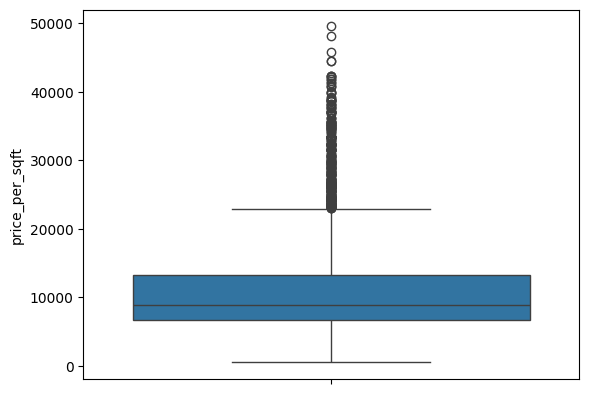

In [76]:
sns.boxplot(df['price_per_sqft'])

In [77]:
df[df['price_per_sqft'] > 42000]


,property_type,society,sector,price,price_per_sqft,Estimated_area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
56,house,independent,sector 55,5.0,44444.0,1125.0,Plot area 125(104.52 sq.m.)Built Up area: 115 ...,9,9,3+,5.0,East,New Property,Not book file and no any financier game. Only ...,NaN,1035.0,900.0,0,0,0,0,1,1,44
484,house,dlf city plots,sector 26,19.0,42054.0,4518.0,Plot area 502(419.74 sq.m.),6,6,3,2.0,East,Relatively New,North east facing a luxury independent house i...,NaN,4518.0,NaN,1,1,0,0,0,1,121
702,house,independent,sector 28,12.0,42194.0,2844.0,Plot area 316(264.22 sq.m.),4,5,3+,4.0,East,Relatively New,"Basement, gf, ff, sf, 4 bhk constructed duplex...",NaN,2844.0,NaN,0,1,1,1,0,1,60
893,house,independent,sector 26,20.0,44444.0,4500.0,Plot area 500(418.06 sq.m.),5,7,3+,3.0,West,Relatively New,"West facing kothi , area- 500 sq yard, \n5bhk-...",NaN,4500.0,NaN,0,1,0,1,0,2,97
1627,house,sushant lok 1 builder floors,sector 43,13.0,48148.0,2700.0,Plot area 300(250.84 sq.m.),3,3,3+,4.0,North,New Property,Sushant lok a block gated line . Floor wise bu...,NaN,2700.0,NaN,0,0,0,1,0,1,7
3052,house,independent,sector 105,9.9,49500.0,2000.0,Built Up area: 2000 (185.81 sq.m.)Carpet area:...,2,2,2,3.0,North,Undefined,"2 bath, semi-Furnished, ground floor (Of 3), n...",NaN,2000.0,1800.0,0,0,0,0,0,0,0
3069,house,independent,sector 26,19.0,42222.0,4500.0,Plot area 500(418.06 sq.m.),6,8,3+,3.0,East,Moderately Old,"Dlf phase 1, gurgaon, haryana\nBeautifully wel...",NaN,4500.0,NaN,1,1,1,1,0,1,103
3804,house,independent,sector 43,9.5,42222.0,2250.0,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,5,5,3+,2.0,North-East,Relatively New,"Sushant lok 1 very prime location , this kothi...",NaN,2700.0,2250.0,0,1,0,1,0,1,88
3928,house,independent,sector 25,13.0,45710.0,2844.0,Plot area 316(264.22 sq.m.),6,8,3+,NaN,Not Available,Relatively New,An impeccable opportunity is here for those wh...,NaN,2844.0,NaN,1,1,1,1,0,2,0


In [78]:
x = df[df['price_per_sqft'] <= 20000]
(x['Estimated_area']/x['bedRoom']).quantile(0.02)

np.float64(170.66)

In [79]:
df[(df['Estimated_area']/df['bedRoom'])<183]

,property_type,society,sector,price,price_per_sqft,Estimated_area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
12,house,independent,sector 48,0.95,8920.0,1065.0,Plot area 1065(98.94 sq.m.),10,10,3+,3.0,Not Available,New Property,Interested to sell independent house/villa con...,NaN,1065.0,NaN,0,0,0,0,0,0,0
24,house,independent,sector 4,0.65,11111.0,585.0,Plot area 65(54.35 sq.m.),4,2,2,NaN,Not Available,Moderately Old,Well maintained two storeyed independent house...,NaN,585.0,NaN,0,0,0,0,0,0,0
56,house,independent,sector 55,5.00,44444.0,1125.0,Plot area 125(104.52 sq.m.)Built Up area: 115 ...,9,9,3+,5.0,East,New Property,Not book file and no any financier game. Only ...,NaN,1035.0,900.0,0,0,0,0,1,1,44
69,house,independent,sector 28,0.45,10000.0,450.0,Built Up area: 50 (4.65 sq.m.),5,3,0,1.0,Not Available,Undefined,Best in class property available at gandhi nag...,NaN,50.0,NaN,0,0,0,0,0,0,0
78,house,independent,sector 3,0.50,11111.0,450.0,Plot area 450(41.81 sq.m.),5,3,3,3.0,Not Available,Moderately Old,I am looking for buyer to purchase house/villa...,NaN,450.0,NaN,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3717,house,independent,sector 105,1.10,12222.0,900.0,Carpet area: 900 (83.61 sq.m.),6,4,1,1.0,South-West,Undefined,Best in class property available at rajendra p...,NaN,NaN,900.0,0,0,0,0,0,0,0
3729,house,housing board colony,sector 28,2.10,23333.0,900.0,Plot area 100(83.61 sq.m.),8,8,3+,4.0,South-East,Moderately Old,"This is park facing 2 bhk on each floor ,maint...",NaN,900.0,NaN,0,0,0,0,1,1,38
3740,house,independent,sector 9,0.22,7407.0,297.0,Carpet area: 33 (27.59 sq.m.),2,2,2,1.0,Not Available,Undefined,Best in class property available at devilal co...,NaN,NaN,33.0,0,0,0,0,0,0,0
3844,house,independent,sector 2,0.98,9074.0,1080.0,Carpet area: 120 (100.34 sq.m.),9,4,3,1.0,South,Undefined,9bhk residential house for resale in palam vih...,NaN,NaN,120.0,0,0,0,0,0,0,0


In [80]:
df.shape

(3731, 24)

In [81]:
min_area_per_bedroom = 150

invalid_mask = (
    (df['property_type'] == 'house') &
    (df['bedRoom'] >= 2) &
    ((df['Estimated_area'] / df['bedRoom']) < min_area_per_bedroom)
)

invalid_mask.sum()


np.int64(60)

In [82]:
df = df.loc[~invalid_mask].reset_index(drop=True)


In [83]:
df.shape

(3671, 24)

In [84]:
# export cleaned data
# df.to_csv('gurgaon_properties_cleaned_v3.csv', index=False)

## Misssing Value Imputation

In [85]:
df.isnull().sum()

property_type             0
society                   0
sector                    0
price                     0
price_per_sqft            0
Estimated_area            0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 16
facing                    0
agePossession             0
description               0
super_built_up_area    1777
built_up_area          2017
carpet_area            1777
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

### Built up area

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

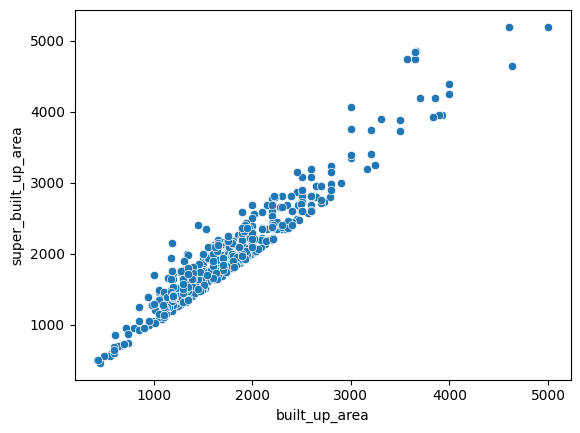

In [87]:
sns.scatterplot(x = df['built_up_area'],y = df['super_built_up_area'])

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

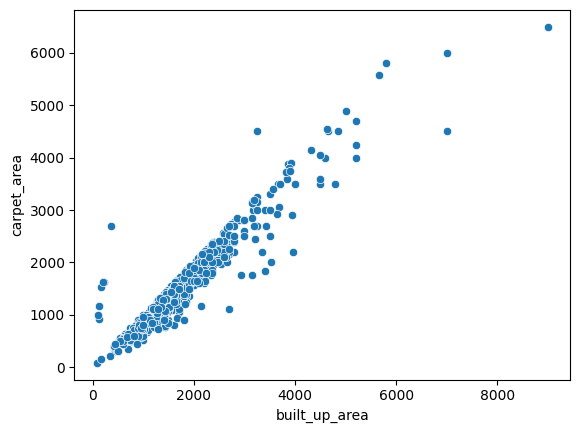

In [88]:
sns.scatterplot(x = df['built_up_area'],y = df['carpet_area'])

In [89]:
((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))

0       False
1       False
2       False
3       False
4       False
        ...  
3666    False
3667    False
3668    False
3669    False
3670    False
Length: 3671, dtype: bool

In [90]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [91]:
all_present_df.shape

(534, 24)

In [92]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [93]:
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [94]:
print(super_to_built_up_ratio, carpet_to_built_up_ratio)

1.1052289815447711 0.9


In [95]:
# both present built up null
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [96]:
sbc_df.head()

,property_type,society,sector,price,price_per_sqft,Estimated_area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
6,flat,dlf the ultima,sector 81,2.30,14375.0,1600.0,Super Built up area 2132(198.07 sq.m.)Carpet a...,3,4,3+,18.0,North-East,Relatively New,3bhk 4baths\nFlat/apartment for sale\nIn dlf t...,2132.0,NaN,1600.0,0,1,0,0,0,1,174
29,flat,gls arawali homes,sector 48,0.30,5291.0,567.0,Super Built up area 567(52.68 sq.m.)Carpet are...,2,2,2,10.0,Not Available,Relatively New,This is society and minimum prize is 5000 sqft,567.0,NaN,467.0,0,0,0,0,0,0,42
33,flat,shree vardhman victoria,sector 70,1.65,8462.0,1950.0,Super Built up area 1950(181.16 sq.m.)Carpet a...,3,4,3,1.0,North,Relatively New,Victoria is a perfect residential complex from...,1950.0,NaN,1267.0,0,1,0,0,0,2,167
38,flat,bestech park view sanskruti,sector 92,1.55,9688.0,1600.0,Super Built up area 1995(185.34 sq.m.)Carpet a...,3,3,3,17.0,Not Available,Relatively New,Bestech sanskruti is well maintained society w...,1995.0,NaN,1600.0,0,1,0,0,0,1,60
43,flat,shapoorji pallonji joyville gurugram,sector 102,1.95,13929.0,1400.0,Super Built up area 1852(172.06 sq.m.)Carpet a...,3,3,3,6.0,North-East,New Property,This 3 bhk flat is located in shapoorji pallon...,1852.0,NaN,1400.0,0,0,0,1,0,1,174


In [97]:
sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)


C:\Users\priya\AppData\Local\Temp\ipykernel_34228\748114042.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)
C:\Users\priya\AppData\Local\Temp\ipykernel_34228\748114042.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

In [98]:
df.update(sbc_df)

In [99]:
df.isnull().sum()

property_type             0
society                   0
sector                    0
price                     0
price_per_sqft            0
Estimated_area            0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 16
facing                    0
agePossession             0
description               0
super_built_up_area    1777
built_up_area          1593
carpet_area            1777
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

In [100]:
# sb present c is null built up null
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [101]:
sb_df.head()

,property_type,society,sector,price,price_per_sqft,Estimated_area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3,flat,supertech araville,sector 79,0.95,6209.0,1530.0,Super Built up area 1530(142.14 sq.m.),2,2,3,7.0,North-East,New Property,"Right next to the new golf course road, m3m an...",1530.0,NaN,NaN,1,0,0,0,0,0,49
4,flat,ambience creacions,sector 22,3.20,11498.0,2783.0,Super Built up area 2781(258.36 sq.m.),3,4,3+,2.0,North-East,New Property,Right in heart of gurgaon and delhi is just 2k...,2781.0,NaN,NaN,0,0,0,0,0,0,42
7,flat,unitech greenwood city,sector 45,2.40,12346.0,1944.0,Super Built up area 216(180.6 sq.m.),3,3,2,1.0,North-West,New Property,Gated society \nCorner property \nNear temple\...,216.0,NaN,NaN,0,1,0,0,0,1,19
8,flat,emaar mgf palm hills,sector 77,1.08,5400.0,2000.0,Super Built up area 2000(185.81 sq.m.),3,4,3+,5.0,South-West,Relatively New,It is basic price advertisement prices depends...,2000.0,NaN,NaN,1,1,0,0,1,1,167
10,flat,unitech the residences,sector 33,1.35,8738.0,1545.0,Super Built up area 1545(143.54 sq.m.),3,4,2,8.0,North-East,Moderately Old,This 3 bhk apartment is available for sale in ...,1545.0,NaN,NaN,0,1,0,0,0,0,49


In [102]:
sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)

C:\Users\priya\AppData\Local\Temp\ipykernel_34228\1714170073.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)
C:\Users\priya\AppData\Local\Temp\ipykernel_34228\1714170073.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df['built_up_area'].fillna(rou

In [103]:
df.update(sb_df)

In [104]:
df.isnull().sum()

property_type             0
society                   0
sector                    0
price                     0
price_per_sqft            0
Estimated_area            0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 16
facing                    0
agePossession             0
description               0
super_built_up_area    1777
built_up_area           706
carpet_area            1777
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

In [105]:
# sb null c is present built up null
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [106]:
c_df.head()

,property_type,society,sector,price,price_per_sqft,Estimated_area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
11,flat,"ganpati apartment 2, laxman vihar phase 1",sector 4,0.45,4707.0,956.0,Carpet area: 850 (78.97 sq.m.),2,2,1,0.0,East,Relatively New,Your search ends here. 2 bhk apartment in laxm...,NaN,NaN,850.0,0,0,0,0,0,0,46
23,flat,signature global solera,sector 107,0.28,5726.0,489.0,Carpet area: 489 (45.43 sq.m.),2,2,2,10.0,South,Relatively New,"Situated in sector 107 gurgaon, signature glob...",NaN,NaN,489.0,0,0,0,0,0,0,38
31,flat,park view apartments,sector 15,1.60,11034.0,1450.0,Carpet area: 1450 (134.71 sq.m.),3,3,3+,2.0,North-West,Moderately Old,A property at the prime location of gurugram w...,NaN,NaN,1450.0,0,0,0,1,0,0,56
32,flat,pioneer park,sector 61,1.60,11594.0,1380.0,Carpet area: 1380 (128.21 sq.m.),2,2,2,21.0,Not Available,Relatively New,Check out this 2 bhk flat for sale in pioneer ...,NaN,NaN,1380.0,0,1,0,0,0,0,105
35,flat,central park flower valley,sector 33,2.50,13270.0,1884.0,Carpet area: 1884 (175.03 sq.m.),3,3,2,1.0,Not Available,Undefined,Best in class property available at sohna loca...,NaN,NaN,1884.0,0,0,0,0,0,0,66


In [107]:
c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)

C:\Users\priya\AppData\Local\Temp\ipykernel_34228\2136919732.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)
C:\Users\priya\AppData\Local\Temp\ipykernel_34228\2136919732.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['built_up_area'].fillna(round(c_df['carp

In [108]:
df.update(c_df)

In [109]:
df.isnull().sum()

property_type             0
society                   0
sector                    0
price                     0
price_per_sqft            0
Estimated_area            0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 16
facing                    0
agePossession             0
description               0
super_built_up_area    1777
built_up_area             5
carpet_area            1777
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

<Axes: xlabel='built_up_area', ylabel='price'>

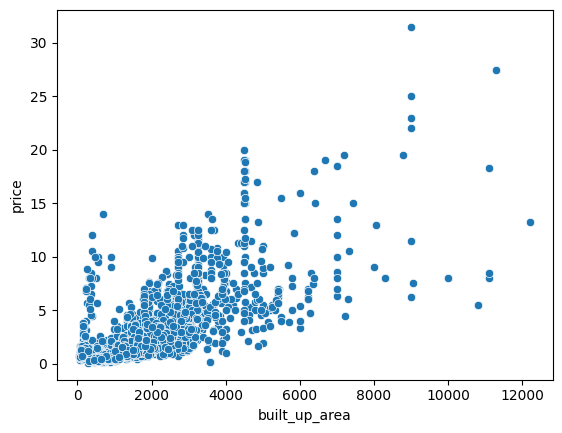

In [111]:
sns.scatterplot(x = df['built_up_area'],y = df['price'])

In [113]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','Estimated_area','built_up_area']]

In [114]:
anamoly_df.sample(5)

,price,Estimated_area,built_up_area
3491,2.51,1696.0,1534.0
2607,3.50,1935.0,1926.0
2899,6.00,3000.0,333.0
2193,3.15,2153.0,222.0
2113,3.75,1467.0,1467.0


In [115]:
anamoly_df['built_up_area'] = anamoly_df['Estimated_area']

In [116]:
df.update(anamoly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

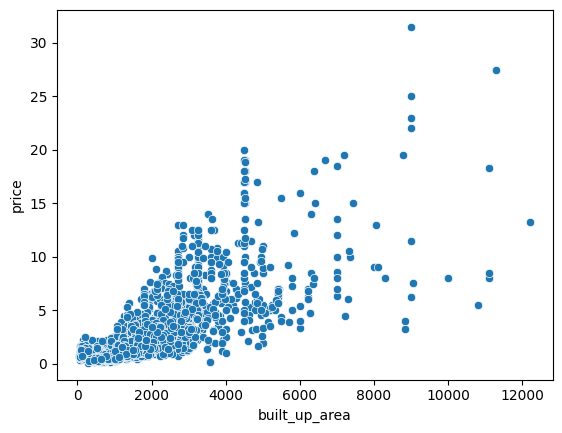

In [118]:
sns.scatterplot(x = df['built_up_area'],y = df['price'])

In [123]:
df.drop(columns=['Estimated_area','areaWithType','super_built_up_area','carpet_area'],inplace=True)

In [124]:
df.isnull().sum()

property_type       0
society             0
sector              0
price               0
price_per_sqft      0
bedRoom             0
bathroom            0
balcony             0
floorNum           16
facing              0
agePossession       0
description         0
built_up_area       5
study room          0
servant room        0
store room          0
pooja room          0
others              0
furnishing_type     0
luxury_score        0
dtype: int64

## floorNum

In [125]:
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
156,house,dlf new town heights,sector 86,2.47,7719.0,4,4,3+,NaN,West,Moderately Old,This is beautiful 4 bhk villa in dlf new town ...,2800.0,0,1,0,1,0,1,130
344,house,independent,sector 26,4.60,12198.0,4,4,3+,NaN,Not Available,Old Property,On the lookout for a spacious house in gurgaon...,3771.0,0,0,0,0,0,0,28
472,house,ansal sushant lok plots,sector 43,3.30,26570.0,1,1,0,NaN,Not Available,Undefined,"Close proximity to gold souk , huda city centr...",1242.0,0,0,0,0,0,0,0
851,house,jacob pura,sector 12,0.35,9722.0,2,1,0,NaN,Not Available,Old Property,Independece house for sale in jacobpura near k...,360.0,0,0,0,0,0,0,0
1043,house,independent,sector 7,6.50,15046.0,3,2,3+,NaN,Not Available,Old Property,Old construction house in new colony gurgaon.,4320.0,0,0,0,0,0,0,9
1730,house,independent,sector 9,1.10,8148.0,2,2,1,NaN,Not Available,Old Property,"2 side open, 1 drawing room, 1 shop, 1 small r...",150.0,0,0,0,0,1,0,0
1756,house,independent,sector 2,5.60,17284.0,8,6,3+,NaN,South-West,Moderately Old,360 sq. Yards plot area near by global foyer m...,3240.0,1,1,1,1,0,0,0
1967,house,independent,sector 3,1.50,10288.0,3,3,0,NaN,Not Available,Old Property,Ground floor and partial first floor built up,1890.0,0,0,0,0,0,0,0
1974,house,independent,sector 110,2.50,5472.0,3,2,1,NaN,Not Available,Old Property,100 mtr from dwarka express way. On 40ft road,4000.0,0,0,0,0,0,0,8
2173,house,emaar mgf marbella,sector 66,9.00,21251.0,4,4,3+,NaN,South-West,Relatively New,A lifestyle designed to satiate all your sense...,5200.0,0,1,1,1,0,1,114


In [126]:
df[df['property_type'] == 'house']['floorNum'].median()

np.float64(2.0)

In [127]:
df['floorNum'].fillna(2.0,inplace=True)

C:\Users\priya\AppData\Local\Temp\ipykernel_34228\15612474.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floorNum'].fillna(2.0,inplace=True)


In [128]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
facing             0
agePossession      0
description        0
built_up_area      5
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [129]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
facing             0
agePossession      0
description        0
built_up_area      5
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [130]:
1011/df.shape[0]

0.27540179787523833

## facing

<Axes: ylabel='count'>

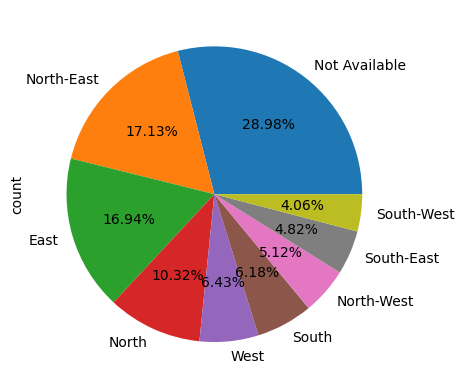

In [131]:
df['facing'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [132]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2543,flat,dlf 76,sector 76,4.00,11429.0,4,4,2,4.0,Not Available,Undefined,This lovely 4 bhk apartment/flat in new gurgao...,3889.0,1,1,0,0,0,1,101
1089,house,suncity essel towers,sector 28,8.95,17900.0,5,6,3+,4.0,Not Available,Moderately Old,"East entry vastu perfect\nLot of daylight, no ...",5000.0,0,0,0,0,0,0,0
2313,house,international city by sobha phase 1,sector 109,6.10,25103.0,5,6,3+,2.0,Not Available,Moderately Old,There is servant room plus servant toilet behi...,2430.0,0,1,0,0,0,0,30
1350,flat,tulip violet,sector 69,1.19,8815.0,2,3,1,0.0,West,Relatively New,This beautiful 2 bhk flat in sector 69 gurgaon...,1500.0,1,0,0,0,0,1,174
934,flat,breeze global heights,sector 33,0.40,6421.0,2,2,2,4.0,Not Available,Undefined,Best in class property available at sector 33 ...,623.0,0,0,0,0,0,0,0


In [133]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
facing             0
agePossession      0
description        0
built_up_area      5
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [134]:
df.drop(index=[2536],inplace=True)

In [135]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
facing             0
agePossession      0
description        0
built_up_area      5
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

## agePossession

In [136]:
df['agePossession'].value_counts()

agePossession
Relatively New        1626
New Property           701
Moderately Old         562
Undefined              333
Old Property           326
Under Construction     122
Name: count, dtype: int64

In [137]:
df[df['agePossession'] == 'Undefined']

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
14,flat,ireo the corridors,sector 67a,1.30,10031.0,2,2,2,-1.0,Not Available,Undefined,Best in class property available at sector 67a...,1296.0,0,0,0,0,0,0,55
17,flat,ansal valley view estate,sector 46,0.60,6452.0,2,2,0,9.0,Not Available,Undefined,Best in class property available at faridabad ...,930.0,0,0,0,0,0,0,0
24,flat,elevate,sector 50,6.75,19882.0,4,4,0,10.0,Not Available,Undefined,Best in class property available at sector 50 ...,3395.0,0,0,0,0,0,0,0
35,flat,central park flower valley,sector 33,2.50,13270.0,3,3,2,1.0,Not Available,Undefined,Best in class property available at sohna loca...,2093.0,0,0,0,0,0,0,66
102,flat,jmd empire,sector 54,1.50,12500.0,2,2,3,7.0,East,Undefined,Best in class property available at golf cours...,1200.0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3649,house,independent,sector 67,3.00,11905.0,4,4,0,3.0,North-East,Undefined,Beautiful house with ready to move option.All ...,2800.0,0,0,0,0,0,0,0
3655,flat,czar mahira homes 63a,sector 63a,0.42,7407.0,3,2,2,-1.0,Not Available,Undefined,Best in class property available at sector 63a...,630.0,0,0,0,0,0,0,0
3658,house,independent,sector 7,0.45,5000.0,3,2,0,1.0,Not Available,Undefined,Villa is available for sale. It carpet area of...,1000.0,0,0,0,0,0,0,0
3661,house,independent,sector 1,4.75,10556.0,6,7,0,4.0,Not Available,Undefined,"6bhk villa for resale in sector 1 gurugram ,pa...",4500.0,0,0,0,0,0,0,0


In [138]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [139]:
df['agePossession'] = df.apply(mode_based_imputation,axis=1)

In [140]:
df['agePossession'].value_counts()

agePossession
Relatively New        1750
New Property           761
Moderately Old         605
Old Property           370
Under Construction     122
Undefined               62
Name: count, dtype: int64

In [141]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [142]:
df['agePossession'] = df.apply(mode_based_imputation2,axis=1)

In [143]:
df['agePossession'].value_counts()

agePossession
Relatively New        1764
New Property           761
Moderately Old         609
Old Property           370
Under Construction     122
Undefined               44
Name: count, dtype: int64

In [144]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [145]:
df['agePossession'] = df.apply(mode_based_imputation3,axis=1)

In [146]:
df['agePossession'].value_counts()

agePossession
Relatively New        1773
New Property           761
Moderately Old         644
Old Property           370
Under Construction     122
Name: count, dtype: int64

In [147]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
facing             0
agePossession      0
description        0
built_up_area      5
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [148]:
# export csv
df.to_csv('OT_MVI.csv')